<a href="https://colab.research.google.com/github/ElFL4/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

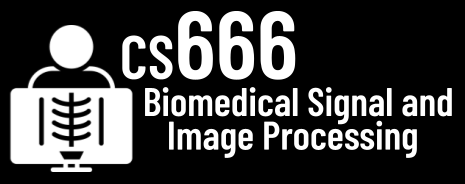
#Assignment 6

In [93]:
# NAME: Elley Lavelle

In [94]:
# In this assignment, we will visualize and explore a CT scan!

In [95]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['axes']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [96]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [97]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [98]:
# TODO: YOUR CODE
!wget -O ct.zip https://cs666.org/data/ct.zip

--2026-05-06 23:06:10--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  --.-KB/s    in 0.08s   

2026-05-06 23:06:10 (67.6 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [99]:
# Then use the following snippet to extract the data.

In [100]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [101]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [102]:
# TODO: YOUR_ANSWER
# 220 Slices

In [103]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [104]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

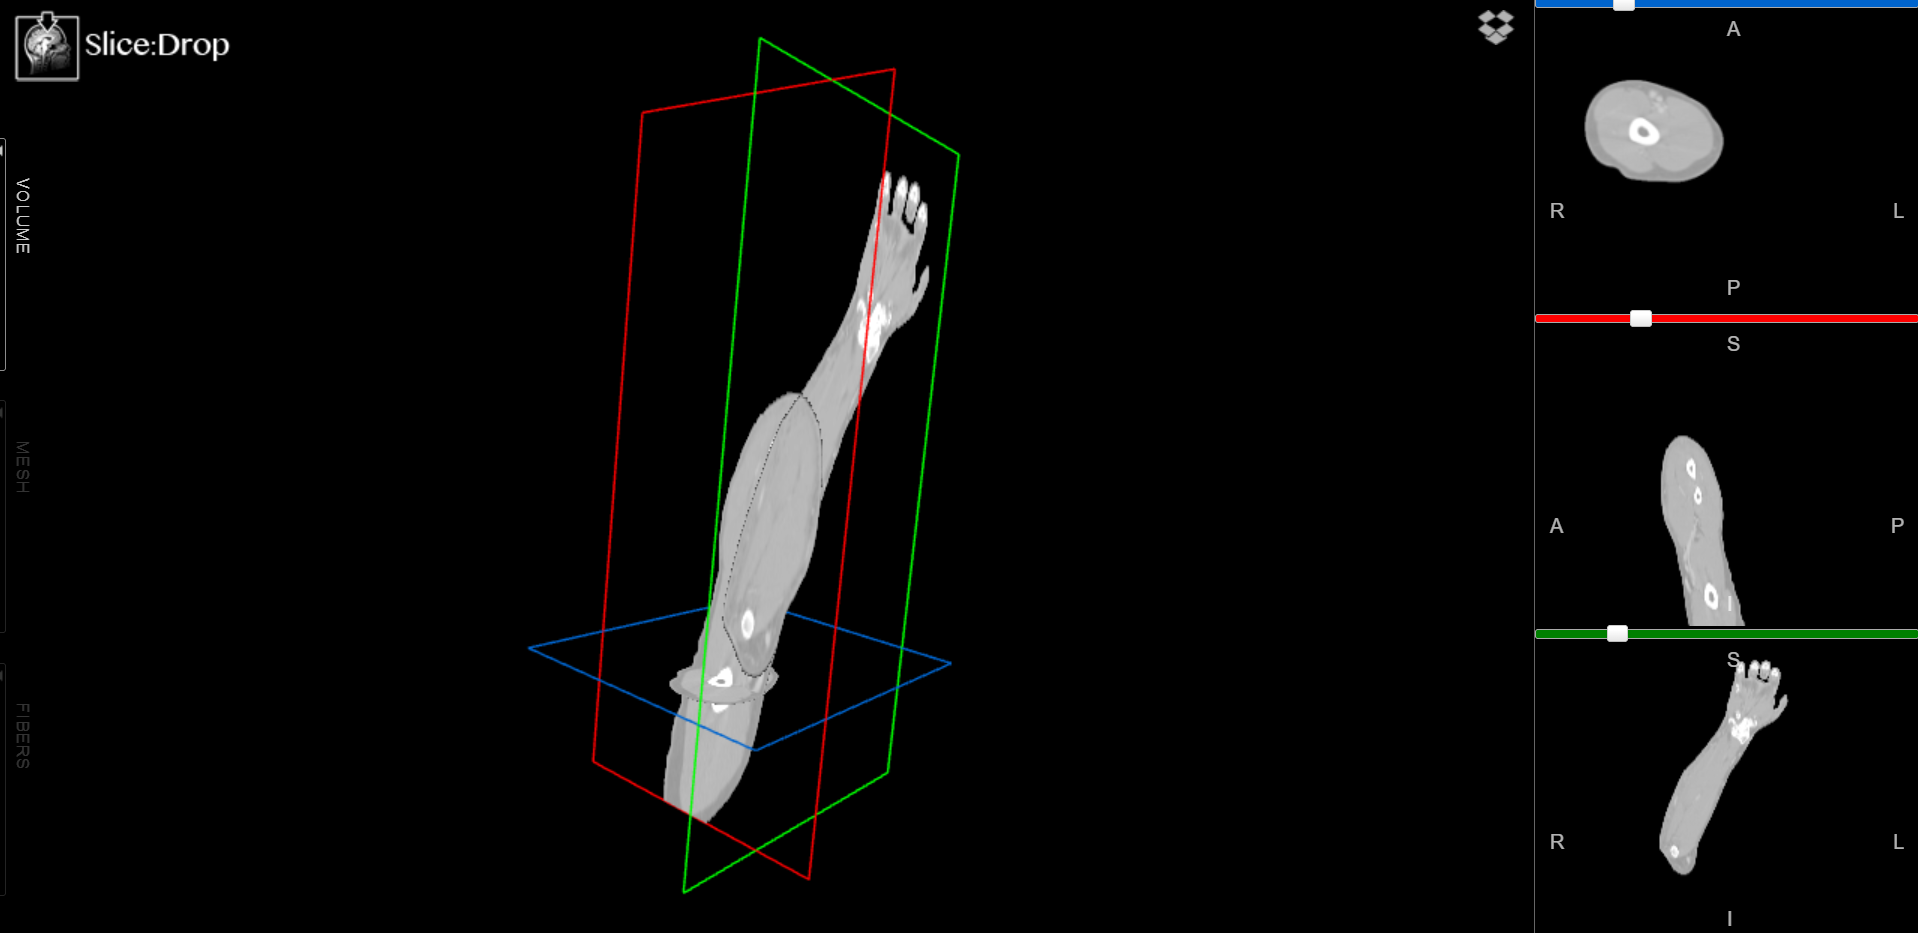

In [105]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [106]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

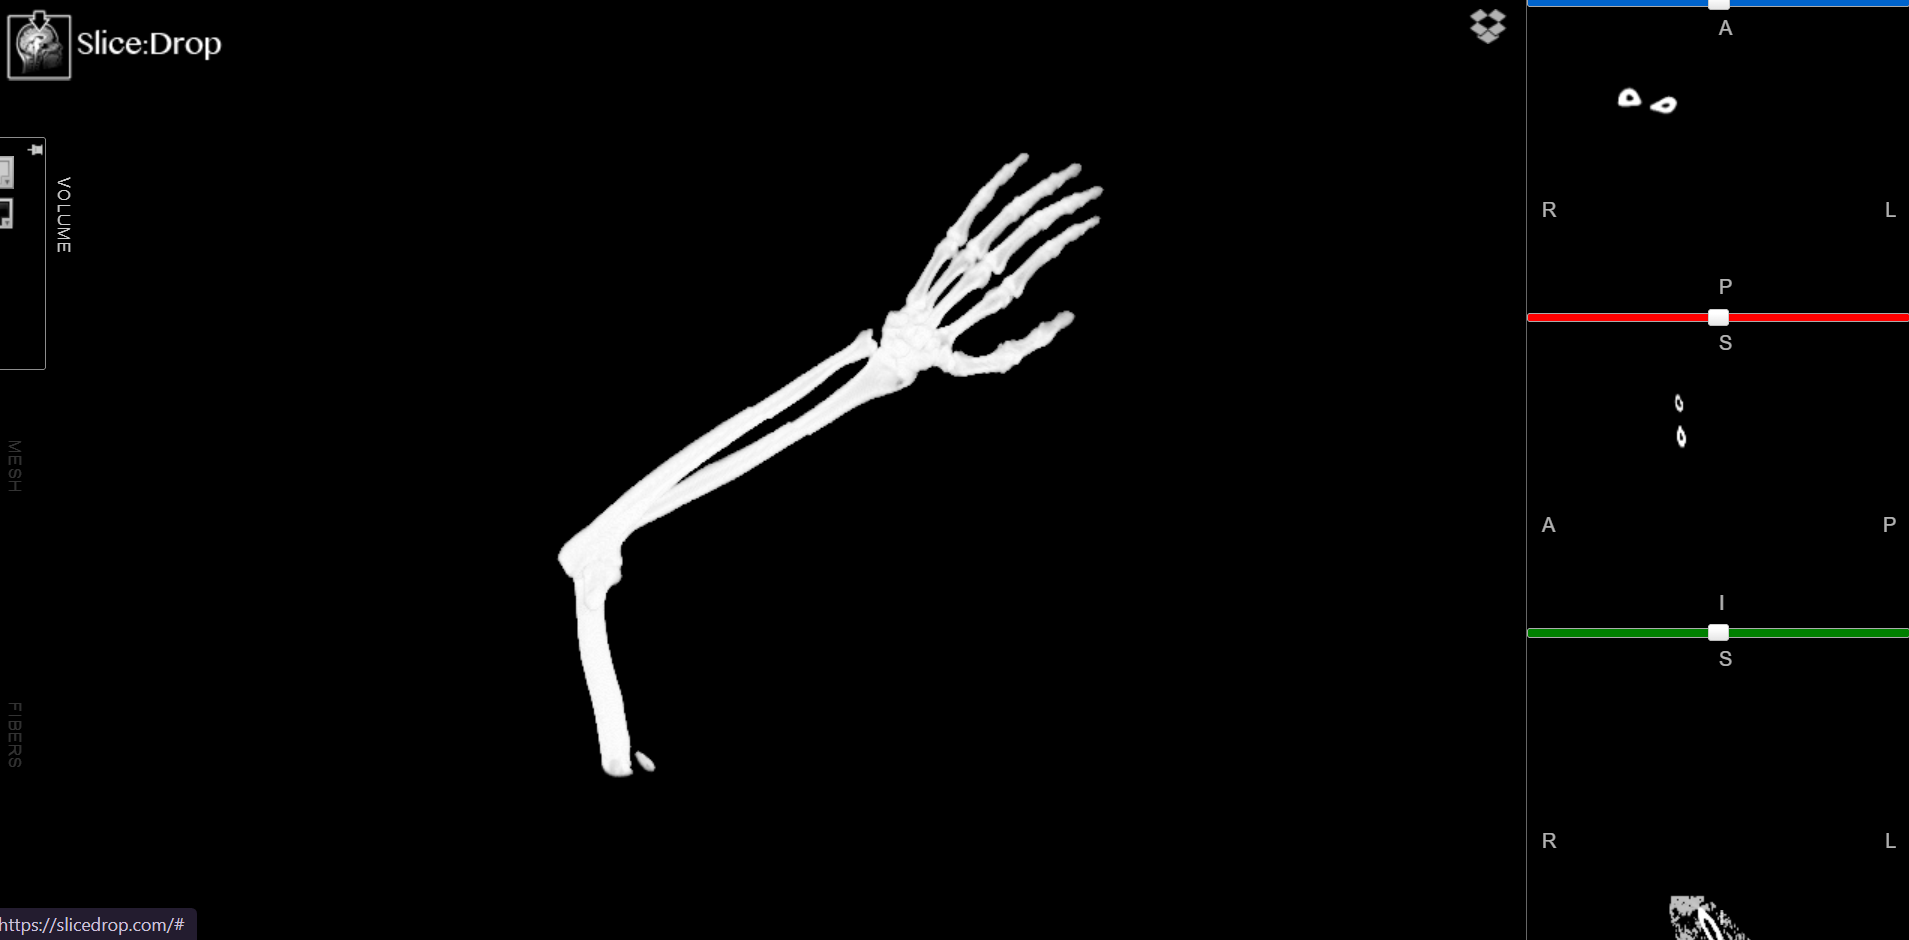

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [107]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [108]:
from pydicom import dcmread

In [109]:
import os

PathDicom = "./ct/"
ListOfDICOM = []

for filename in os.listdir(PathDicom):
    if ".dcm" in filename.lower():
        ListOfDICOM.append(os.path.join(PathDicom, filename))
ListOfDICOM.sort()

ds = dcmread(ListOfDICOM[0])

ConstPixelDims = (len(ListOfDICOM), int(ds.Rows), int(ds.Columns))
ArrayDicom = np.zeros(ConstPixelDims, dtype=ds.pixel_array.dtype)

for i, file_path in enumerate(ListOfDICOM):
    ds = dcmread(file_path)
    ArrayDicom[i, :, :] = ds.pixel_array

print(f"Loaded {len(ListOfDICOM)} slices into a 3D numpy array with shape {ArrayDicom.shape}")

Loaded 220 slices into a 3D numpy array with shape (220, 454, 512)


In [110]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

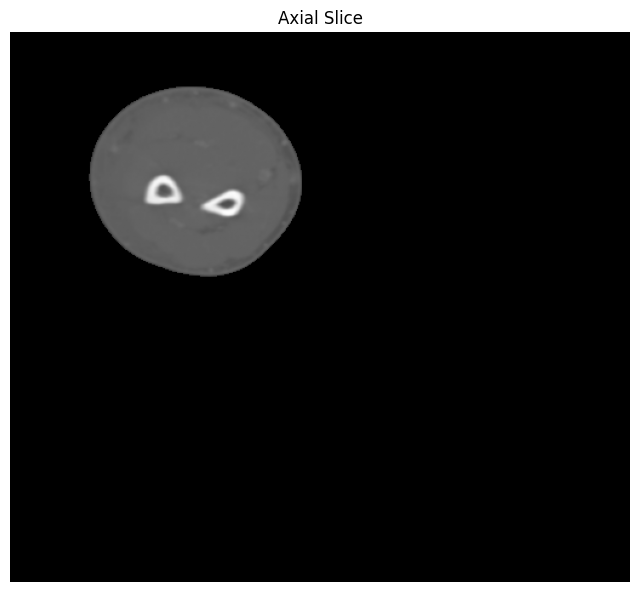

In [111]:
# TODO: YOUR CODE FOR AXIAL

axial_slice = ArrayDicom[ArrayDicom.shape[0] // 2, :, :]
plt.figure(figsize=(8, 8))
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial Slice')
plt.axis('off')
plt.show()

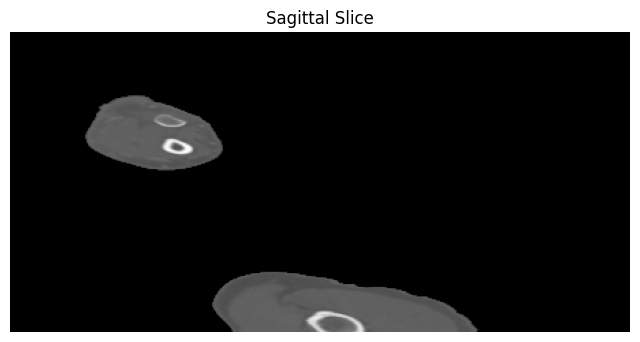

In [112]:
sagittal_slice = ArrayDicom[:, :, ArrayDicom.shape[2] // 2]
plt.figure(figsize=(8, 8))
plt.imshow(sagittal_slice, cmap='gray')
plt.title('Sagittal Slice')
plt.axis('off')
plt.show()

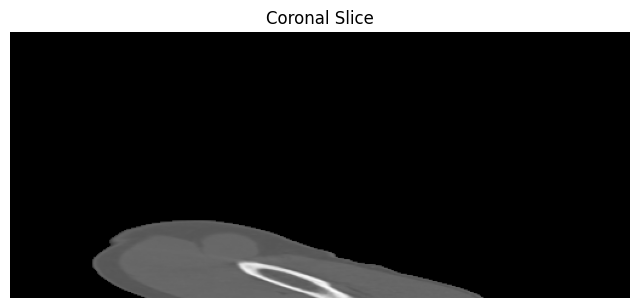

In [113]:
coronal_slice = ArrayDicom[:, ArrayDicom.shape[1] // 2, :]
plt.figure(figsize=(8, 8))
plt.imshow(coronal_slice, cmap='gray')
plt.title('Coronal Slice')
plt.axis('off')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [114]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [115]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [116]:
# TODO: YOUR CODE

Window Center (Level): 30
Window Width: 410
Rescale Intercept: -1024


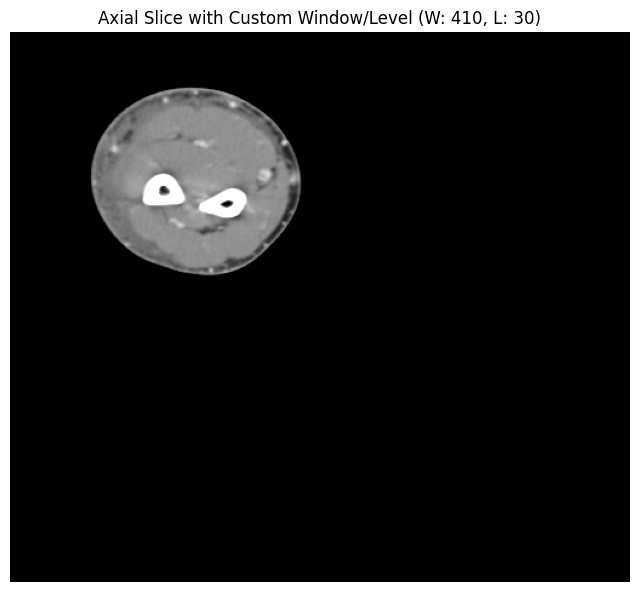

In [117]:
ds = dcmread(ListOfDICOM[0])

window_center = ds[0x0028, 0x1050].value
window_width = ds[0x0028, 0x1051].value
rescale_intercept = ds[0x0028, 0x1052].value

if isinstance(window_center, list):
    window_center = window_center[0]
if isinstance(window_width, list):
    window_width = window_width[0]

print(f"Window Center (Level): {window_center}")
print(f"Window Width: {window_width}")
print(f"Rescale Intercept: {rescale_intercept}")

hu_pixels = ArrayDicom[ArrayDicom.shape[0] // 2, :, :] + rescale_intercept
vmin = window_center - window_width / 2
vmax = window_center + window_width / 2

plt.figure(figsize=(8, 8))
plt.imshow(hu_pixels, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f'Axial Slice with Custom Window/Level (W: {window_width}, L: {window_center})')
plt.axis('off')
plt.show()

In [118]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

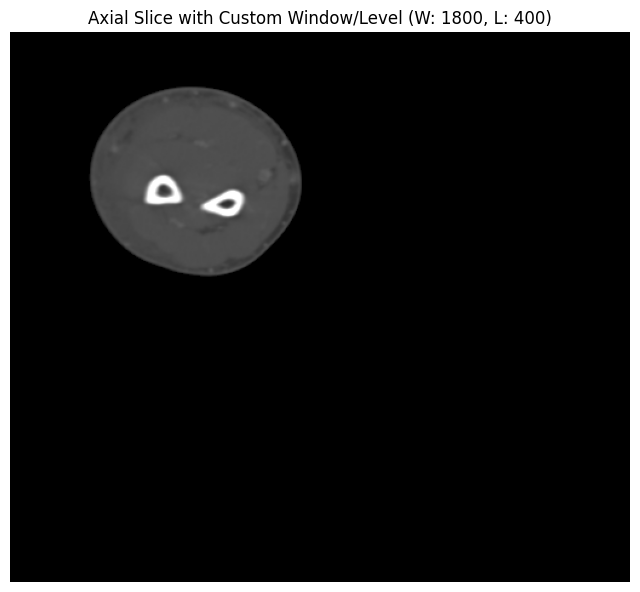

In [119]:
custom_window_width = 1800
custom_window_level = 400

hu_pixels = ArrayDicom[ArrayDicom.shape[0] // 2, :, :].astype(np.float32) + rescale_intercept

vmin_custom = custom_window_level - custom_window_width / 2
vmax_custom = custom_window_level + custom_window_width / 2

plt.figure(figsize=(8, 8))
plt.imshow(hu_pixels, cmap='gray', vmin=vmin_custom, vmax=vmax_custom)
plt.title(f'Axial Slice with Custom Window/Level (W: {custom_window_width}, L: {custom_window_level})')
plt.axis('off')
plt.show()

In [120]:
# Which values make sense and why?

In [121]:
# TODO: YOUR ANSWER

In [122]:
# Window level 30, window width 410 make more sense because there
# is more visual contrast between the bone, soft tissue, and fat within
# the scan to me.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [123]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [124]:
# TODO: YOUR CODE TO SEGMENT FAT

Fat mask shape: (220, 454, 512)


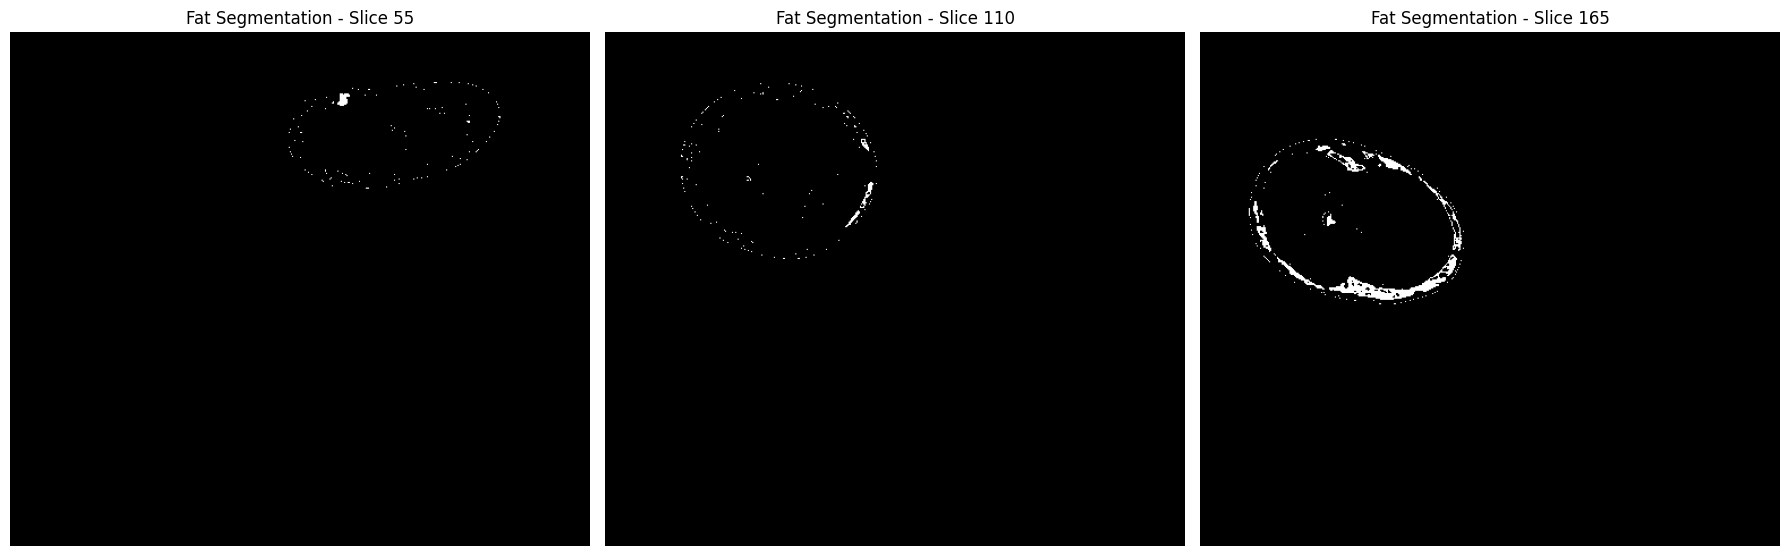

In [125]:
hu_volume = ArrayDicom.astype(np.int16) + rescale_intercept

fat_mask = hu_volume.copy()
fat_mask[ (fat_mask >= -120) & (fat_mask <= -90) ] = 1
fat_mask[fat_mask != 1] = 0
fat_mask = fat_mask.astype(np.int16)

print(f"Fat mask shape: {fat_mask.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

slices_to_show = [fat_mask.shape[0] // 4, fat_mask.shape[0] // 2, fat_mask.shape[0] * 3 // 4]

for i, slice_idx in enumerate(slices_to_show):
    axes[i].imshow(fat_mask[slice_idx, :, :], cmap='gray')
    axes[i].set_title(f'Fat Segmentation - Slice {slice_idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [126]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

Soft tissue mask shape: (220, 454, 512)


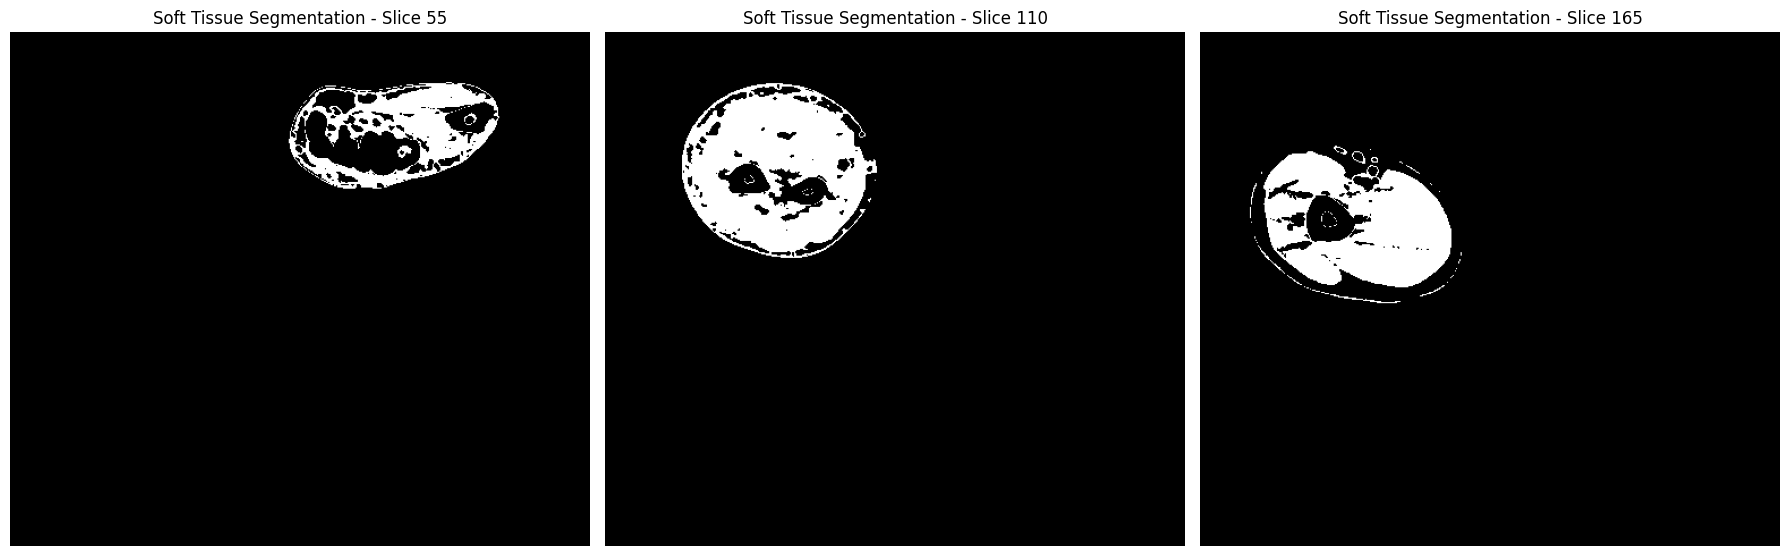

In [127]:
soft_tissue_mask = hu_volume.copy()
soft_tissue_mask[ (soft_tissue_mask >= 0) & (soft_tissue_mask <= 80) ] = 1
soft_tissue_mask[soft_tissue_mask != 1] = 0
soft_tissue_mask = soft_tissue_mask.astype(np.int16)

print(f"Soft tissue mask shape: {soft_tissue_mask.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

slices_to_show = [soft_tissue_mask.shape[0] // 4, soft_tissue_mask.shape[0] // 2, soft_tissue_mask.shape[0] * 3 // 4]

for i, slice_idx in enumerate(slices_to_show):
    axes[i].imshow(soft_tissue_mask[slice_idx, :, :], cmap='gray')
    axes[i].set_title(f'Soft Tissue Segmentation - Slice {slice_idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [128]:
# TODO: YOUR CODE TO SEGMENT BONES

Bones mask shape: (220, 454, 512)


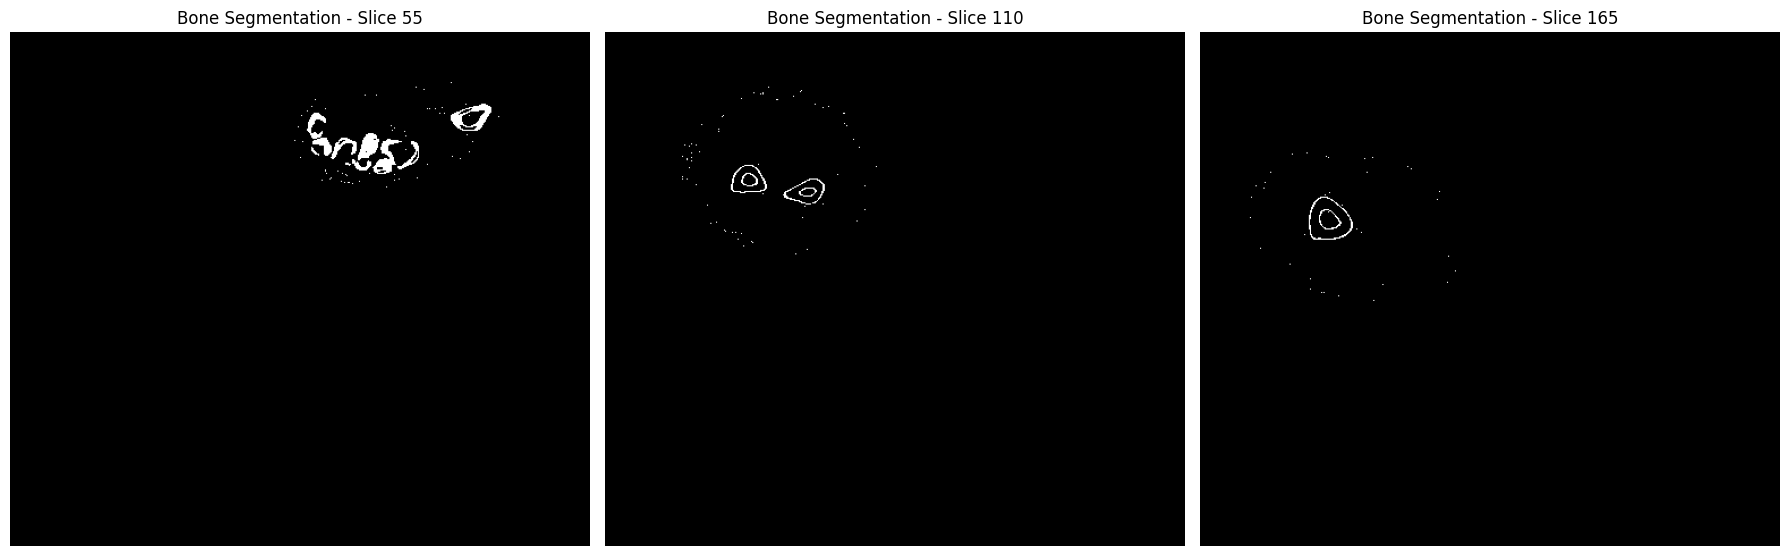

In [129]:
bones_mask = hu_volume.copy()
bones_mask[ (bones_mask >= 400) & (bones_mask <= 1000) ] = 1
bones_mask[bones_mask != 1] = 0
bones_mask = bones_mask.astype(np.int16)

print(f"Bones mask shape: {bones_mask.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

slices_to_show = [bones_mask.shape[0] // 4, bones_mask.shape[0] // 2, bones_mask.shape[0] * 3 // 4]

for i, slice_idx in enumerate(slices_to_show):
    axes[i].imshow(bones_mask[slice_idx, :, :], cmap='gray')
    axes[i].set_title(f'Bone Segmentation - Slice {slice_idx}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [130]:
# Are the segmentations good?

In [131]:
# TODO: YOUR ANSWER

In [131]:
# They're mostly good but the bone segmentations could be better in my opinion.
# They seem to have a lot of artifacts around the edges.

In [132]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""